In [1]:
print("starting")

starting


Loading POD coefficients...


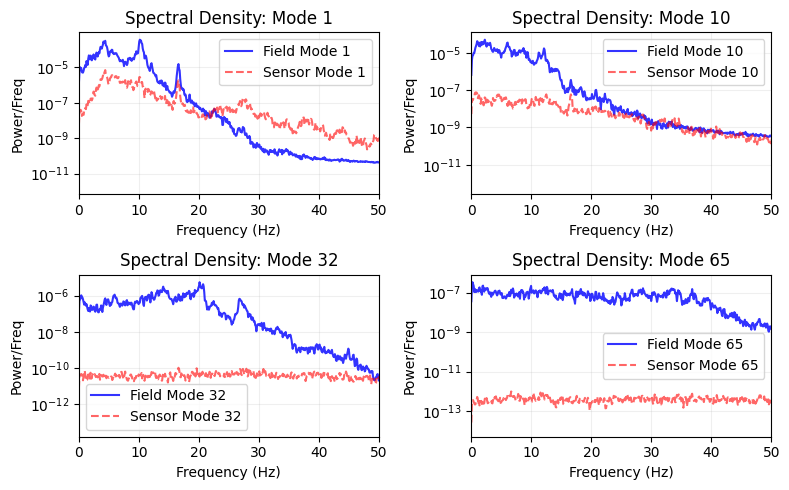

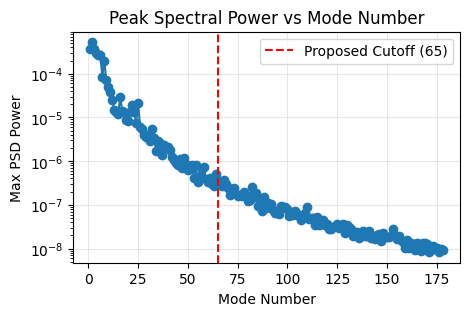

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import os

# --- 1. Config ---
output_dir = "/media/chris-remote/Projects/ONeill/estimation/output/kevin_2cylinder"
data_path = os.path.join(output_dir, "lstm_ready_data_FF.h5")
fs = 200.0  # Assuming dt=0.005. Adjust if your simulation dt is different!

# --- 2. Load Coefficients ---
print("Loading POD coefficients...")
with h5py.File(data_path, 'r') as f:
    # We analyze the high-rate training data to see the "truth"
    a_ff = f['train/a_ff'][:] # (N_time, 178)
    a_ss = f['train/a_ss'][:] # (N_time, 267)

# --- 3. Compute PSDs ---
def get_psd(data, fs):
    # nperseg should be long enough to resolve the low-frequency flip-flop
    freqs, psd = welch(data, fs=fs, nperseg=2048)
    return freqs, psd

modes_to_plot = [0, 9, 31, 64] # Modes 1, 10, 32, 65
plt.figure(figsize=(8, 5))

for i, m_idx in enumerate(modes_to_plot):
    f_ff, p_ff = get_psd(a_ff[:, m_idx], fs)
    f_ss, p_ss = get_psd(a_ss[:, m_idx], fs)
    
    plt.subplot(2, 2, i+1)
    plt.semilogy(f_ff, p_ff, label=f'Field Mode {m_idx+1}', color='blue', alpha=0.8)
    plt.semilogy(f_ss, p_ss, label=f'Sensor Mode {m_idx+1}', color='red', linestyle='--', alpha=0.6)
    
    plt.title(f"Spectral Density: Mode {m_idx+1}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power/Freq")
    plt.grid(True, which='both', alpha=0.2)
    plt.legend()
    plt.xlim(0, 50) # Focus on the primary physical range

plt.tight_layout()
plt.show()

# --- 4. Spectral Floor Analysis ---
# Plotting the Peak Power of each mode to see where it hits the noise floor
peak_powers = []
for m in range(min(178, a_ff.shape[1])):
    _, p = get_psd(a_ff[:, m], fs)
    peak_powers.append(np.max(p))

plt.figure(figsize=(5, 3))
plt.plot(range(1, len(peak_powers)+1), peak_powers, 'o-')
plt.yscale('log')
plt.title("Peak Spectral Power vs Mode Number")
plt.xlabel("Mode Number")
plt.ylabel("Max PSD Power")
plt.axvline(65, color='r', linestyle='--', label='Proposed Cutoff (65)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()